In [3]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

[8.99683277e-01 4.61758625e+03]
[3.08533883e-02 5.63750179e+01]
[  0.56343022 151.66116817]
[  2.04613354 169.7552002 ]
[7.16420455e-01 2.27344339e+03]
[5.94543800e-02 6.27915856e+01]


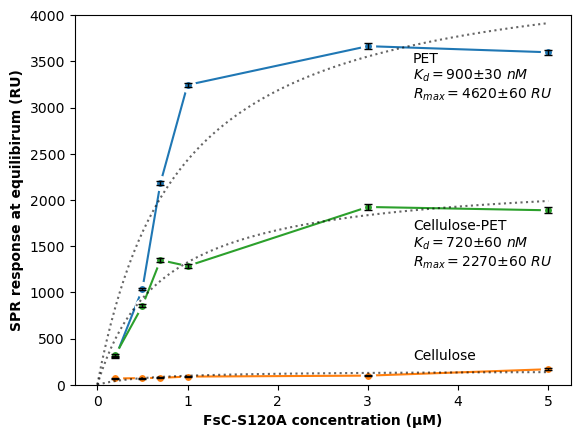

In [16]:
files = ['0.25% PET_results.csv', '0.25% Cellulose_results.csv', 'CellulosePET_results.csv']
names = ['PET', 'Cellulose', 'Cellulose-PET']
ru = np.array([4.91, 1.84, 2.83]) * 1e3
ru_err = np.array([0.04, 0.15, 0.05]) * 1e3

shift = [-500, 100, -600]

yerr_frac = ru_err / ru

def langmuir(x, kd, bmax):
    return (x * bmax) / (kd + x)

for i,file in enumerate(files):
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    x = data[:,0]
    y = data[:,1]

    popt, pcov = curve_fit(langmuir, x, y, sigma=ru_err[i], absolute_sigma=True, p0 = [1000, 10000])
    perr = np.sqrt(np.diag(pcov))
    if i != 1:
        rounded_err_0= np.round(perr[0]*1000, -1)
        rounded_p_0 = np.round(popt[0]*1000, -1)
        rounded_err_1= np.round(perr[1], -1)
        rounded_p_1 = np.round(popt[1], -1)

        plt.text( x[-1]-1.5, y[-1]+shift[i], f'{names[i]}\n$K_d={rounded_p_0:.0f} ± {rounded_err_0:.0f}~nM$\n$R_{{max}}={rounded_p_1:.0f} ± {rounded_err_1:.0f}~RU$')
    else:
        plt.text( x[-1]-1.5, y[-1]+shift[i], f'{names[i]}')


    plt.plot(x, y, marker='o', linestyle='-', markeredgecolor='w', markersize=8, markeredgewidth=3, label=names[i])
    plt.errorbar(x,y, yerr=yerr_frac[i]*y, fmt='none', ecolor='k', elinewidth=1, capsize=3, zorder=10)

    xmodel = np.linspace(0, max(x), 100)
    if i == 0:
        plt.plot(xmodel, langmuir(xmodel, *popt), 'k:', label=f' Fits', alpha=0.6)

    else:
        plt.plot(xmodel, langmuir(xmodel, *popt), 'k:', alpha=0.6)

        
    print(popt)
    print(perr)

plt.ylim(0,4000)
plt.ylabel ('SPR response at equilibirum (RU)', fontsize=10, fontweight='bold')
plt.xlabel ('FsC-S120A concentration (µM)', fontsize=10,fontweight='bold')
#plt.legend(fontsize=8,borderpad=0.1, labelspacing=0.4)
plt.savefig('SPR_langmuir.png', dpi=300)
    